In [ ]:
# ===============================
# STEP 1: Install Dependencies
# ===============================

!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from google.colab import files

In [ ]:
# ===============================
# STEP 2: Load and Prepare Unified Monthly Cost Index (Labor, Materials, Equipment)
# ===============================

# Upload cleaned files from your computer
uploaded = files.upload()

# Load your monthly skeleton dataset (already cleaned)
df = pd.read_csv("Cleaned_Monthly_Skeleton_2014_2024.csv")

# Normalize column names and values
df.columns = df.columns.str.strip().str.replace('\xa0', ' ', regex=True)
df["Major Groups"] = df["Major Groups"].astype(str).str.strip()

# Extract the key cost categories
key_groups = ["Raw Materials", "Rental of equipment", "Labor costs and wages"]
df = df[df["Major Groups"].isin(key_groups)]

# Reshape to long format, then pivot
df_long = df.set_index("Major Groups").T.reset_index()
df_long = df_long.rename(columns={"index": "Month"})

# Melt and pivot to get tidy columns
df_long = df_long.melt(id_vars="Month", var_name="Component", value_name="Index")
df_pivot = df_long.pivot(index="Month", columns="Component", values="Index").reset_index()

# Remove rows like 'Avg. 2014'
df_pivot = df_pivot[~df_pivot["Month"].str.contains("Avg", na=False)]

# Convert 'Month' to datetime (keep only rows that match 'Mon. YYYY' format)
df_pivot = df_pivot[df_pivot["Month"].str.match(r"^[A-Z][a-z]{2}\. \d{4}$", na=False)]
df_pivot["Date"] = pd.to_datetime(df_pivot["Month"].str.strip(), format="%b. %Y")
df_pivot = df_pivot.drop(columns="Month").set_index("Date")

# Convert all data to numeric
df_pivot = df_pivot.apply(pd.to_numeric, errors='coerce')

# Preview your unified monthly index
df_pivot.tail()

Saving Cleaned_Dec_2024_Jan_2025.csv to Cleaned_Dec_2024_Jan_2025 (1).csv
Saving Cleaned_Household_Budget_2017.csv to Cleaned_Household_Budget_2017 (1).csv
Saving Cleaned_Monthly_Skeleton_2014_2024.csv to Cleaned_Monthly_Skeleton_2014_2024 (1).csv
Saving Cleaned_Non_Residential_2008_2024.csv to Cleaned_Non_Residential_2008_2024 (1).csv
Saving Cleaned_Residential_2008_2024.csv to Cleaned_Residential_2008_2024 (1).csv
Saving Cleaned_Residential_Indices.csv to Cleaned_Residential_Indices (1).csv
Saving Cleaned_Skeleton_2013_2024.csv to Cleaned_Skeleton_2013_2024 (1).csv
Saving Cleaned_Skeleton_Indices.csv to Cleaned_Skeleton_Indices (1).csv


Component,Labor costs and wages,Raw Materials,Rental of equipment
Date,,,
2014-03-01,100.84,100.21,101.28
2014-05-01,100.84,99.84,102.21
2014-11-01,101.94,99.93,101.24
2014-10-01,101.94,100.26,101.63
2014-09-01,101.94,99.99,102.89


In [ ]:
# ===============================
# STEP 3: Forecast Labor, Materials, and Equipment Costs for 2025
# ===============================

from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt

def forecast_index(series, periods=12):
    """
    Forecasts future values using Holt-Winters or Holt trend (if not enough data).
    """
    if len(series) < 24:
        print(f"⚠ Not enough data for Holt-Winters on {series.name}. Using Holt Trend.")
        model = Holt(series)
    else:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12)
    fit = model.fit()
    forecast = fit.forecast(periods)
    return forecast

# Forecast each cost component for 12 months (2025)
labor_forecast = forecast_index(df_pivot["Labor costs and wages"])
materials_forecast = forecast_index(df_pivot["Raw Materials"])
equipment_forecast = forecast_index(df_pivot["Rental of equipment"])

# Preview
print("📈 Labor Forecast 2025")
print(labor_forecast)
print("\n📈 Materials Forecast 2025")
print(materials_forecast)
print("\n📈 Equipment Forecast 2025")
print(equipment_forecast)


⚠ Not enough data for Holt-Winters on Labor costs and wages. Using Holt Trend.
⚠ Not enough data for Holt-Winters on Raw Materials. Using Holt Trend.
⚠ Not enough data for Holt-Winters on Rental of equipment. Using Holt Trend.
📈 Labor Forecast 2025
12    102.170990
13    102.350883
14    102.530776
15    102.710669
16    102.890563
17    103.070456
18    103.250349
19    103.430242
20    103.610135
21    103.790029
22    103.969922
23    104.149815
dtype: float64

📈 Materials Forecast 2025
12    100.098107
13    100.091840
14    100.085573
15    100.079306
16    100.073039
17    100.066772
18    100.060505
19    100.054238
20    100.047971
21    100.041704
22    100.035437
23    100.029170
dtype: float64

📈 Equipment Forecast 2025
12    102.922195
13    103.148412
14    103.374628
15    103.600845
16    103.827061
17    104.053278
18    104.279494
19    104.505711
20    104.731927
21    104.958144
22    105.184360
23    105.410577
dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.1

In [ ]:
# ===============================
# STEP 4: Apply Forecasted Indices to Real Construction Costs (USD/unit)
# ===============================
# Example base 2023 costs
base_2023_costs = {
    'cement': 75,      # USD/ton
    'steel': 1100,     # USD/ton
    'sand': 35,        # USD/ton
    'stone': 56,       # USD/ton
    'gravel': 21,      # USD/ton
    'lumber': 300,     # USD/m³
    'labor': 200,      # USD/m² (aggregate construction labor)
    'water': 3         # USD/m³
}

# Use average forecasted index for 2025
avg_labor_idx_2025 = labor_forecast.mean()
avg_mat_idx_2025 = materials_forecast.mean()
avg_equip_idx_2025 = equipment_forecast.mean()

# Use Dec 2024 index as base point (last row in df_pivot)
idx_2024_labor = df_pivot["Labor costs and wages"].iloc[-1]
idx_2024_mat = df_pivot["Raw Materials"].iloc[-1]

def adjust_cost(base, index_2024, index_2025):
    """Apply index-based inflation adjustment."""
    return base * (index_2025 / index_2024)

cost_forecast_2025 = {}
for component, base_cost in base_2023_costs.items():
    if component == 'labor':
        cost_forecast_2025[component] = adjust_cost(base_cost, idx_2024_labor, avg_labor_idx_2025)
    else:
        cost_forecast_2025[component] = adjust_cost(base_cost, idx_2024_mat, avg_mat_idx_2025)

forecast_series = pd.Series(cost_forecast_2025, name="Predicted 2025 Cost (USD/unit)")
forecast_series.index.name = "Component"

print("\n📊 Forecasted 2025 Unit Costs (USD)")
display(forecast_series)



📊 Forecasted 2025 Unit Costs (USD)


,Predicted 2025 Cost (USD/unit)
Component,
cement,75.055234
steel,1100.810105
sand,35.025776
stone,56.041242
gravel,21.015466
lumber,300.220938
labor,202.394354
water,3.002209


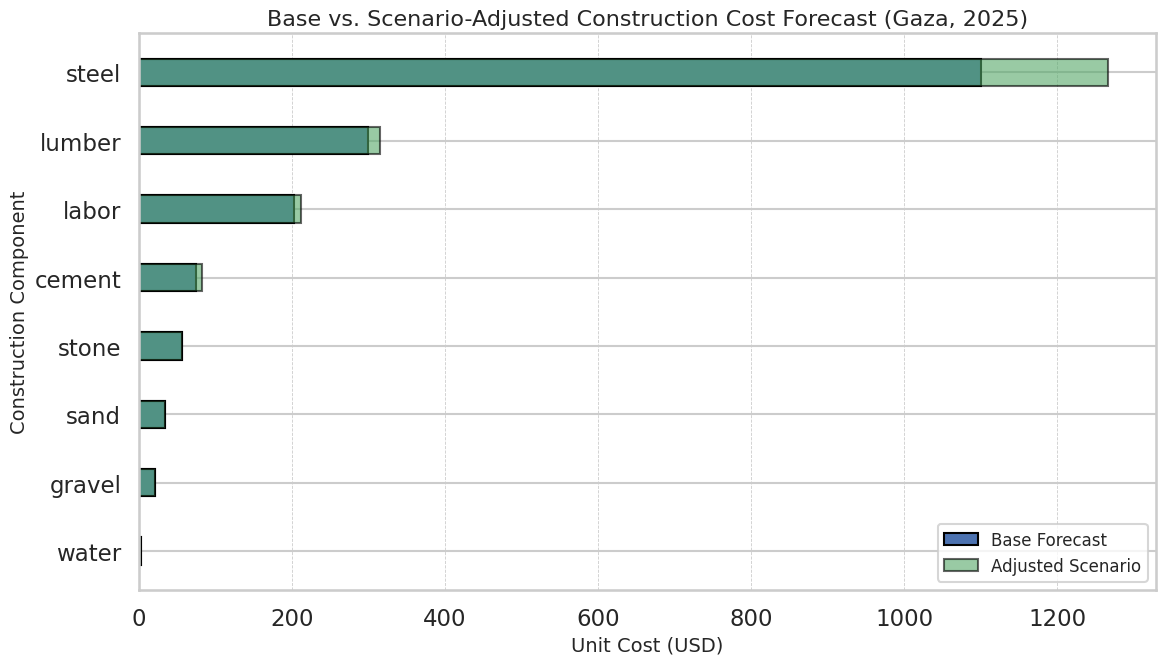

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Optional: Activate academic-friendly plot style
sns.set(style="whitegrid", context="talk")

# ----- SORTED SERIES -----
sorted_base = forecast_series.sort_values(ascending=True)
sorted_adjusted = pd.Series({
    comp: round(forecast_series[comp] * scenario_multipliers.get(comp, 1.0), 2)
    for comp in sorted_base.index
}, name="Adjusted Forecast")

# ----- PLOT: Side-by-side bar chart -----
fig, ax = plt.subplots(figsize=(12, 7))

# Plot base forecast bars
ax.barh(
    sorted_base.index,
    sorted_base.values,
    label="Base Forecast",
    height=0.4,
    color="#4C72B0",
    edgecolor='black'
)

# Overlay adjusted bars
ax.barh(
    sorted_adjusted.index,
    sorted_adjusted.values,
    label="Adjusted Scenario",
    height=0.4,
    left=0,  # aligns to base
    alpha=0.6,
    color="#55A868",
    edgecolor='black'
)

# ----- LABELING -----
ax.set_title("Base vs. Scenario-Adjusted Construction Cost Forecast (Gaza, 2025)", fontsize=16)
ax.set_xlabel("Unit Cost (USD)", fontsize=14)
ax.set_ylabel("Construction Component", fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.6)

# Tight layout for cleaner appearance
plt.tight_layout()
plt.show()


In [ ]:
# Define a dictionary mapping each component to its unit of measurement
units_dict = {
    'cement': "USD/ton",
    'steel': "USD/ton",
    'sand': "USD/ton",
    'stone': "USD/ton",
    'gravel': "USD/ton",
    'lumber': "USD/m³",
    'labor': "USD/m²",
    'water': "USD/m³"
}

# Convert the forecast_series (with predicted costs) to a DataFrame
cost_df = forecast_series.reset_index()
cost_df.columns = ["Component", "Predicted 2025 Cost"]

# Map each component to its unit using the units_dict
cost_df["Unit"] = cost_df["Component"].map(units_dict)

# Preview the DataFrame
print(cost_df)

# Save the DataFrame to a CSV file
cost_df.to_csv("forecasted_costs_2025.csv", index=False)
print("\nCSV file 'forecasted_costs_2025.csv' has been saved.")

  Component  Predicted 2025 Cost     Unit
0    cement            75.055234  USD/ton
1     steel          1100.810105  USD/ton
2      sand            35.025776  USD/ton
3     stone            56.041242  USD/ton
4    gravel            21.015466  USD/ton
5    lumber           300.220938   USD/m³
6     labor           202.394354   USD/m²
7     water             3.002209   USD/m³

CSV file 'forecasted_costs_2025.csv' has been saved.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt

def forecast_index(series, periods=12):
    if len(series) < 24:
        model = Holt(series)
    else:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12)
    fit = model.fit()
    forecast = fit.forecast(periods)
    return series, forecast

# Assuming df_pivot was already defined earlier in your notebook and contains the indexed time series:
labor_series, labor_forecast = forecast_index(df_pivot["Labor costs and wages"])
materials_series, materials_forecast = forecast_index(df_pivot["Raw Materials"])
equipment_series, equipment_forecast = forecast_index(df_pivot["Rental of equipment"])


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.1